**Experiment 1:**

In [10]:

import random


# Create a random list length "length" containing whole numbers between 0 and max_value inclusive
def create_random_list(length, max_value):
    return [random.randint(0, max_value) for _ in range(length)]


# Creates a near sorted list by creating a random list, sorting it, then doing a random number of swaps
def create_near_sorted_list(length, max_value, swaps):
    L = create_random_list(length, max_value)
    L.sort()
    for _ in range(swaps):
        r1 = random.randint(0, length - 1)
        r2 = random.randint(0, length - 1)
        swap(L, r1, r2)
    return L


# I have created this function to make the sorting algorithm code read easier
def swap(L, i, j):
    L[i], L[j] = L[j], L[i]


# ******************* Insertion sort code *******************

# This is the traditional implementation of Insertion Sort.
def insertion_sort(L):
    for i in range(1, len(L)):
        insert(L, i)


def insert(L, i):
    while i > 0:
        if L[i] < L[i-1]:
            swap(L, i-1, i)
            i -= 1
        else:
            return


# This is the optimization/improvement we saw in lecture
def insertion_sort2(L):
    for i in range(1, len(L)):
        insert2(L, i)


def insert2(L, i):
    value = L[i]
    while i > 0:
        if L[i - 1] > value:
            L[i] = L[i - 1]
            i -= 1
        else:
            L[i] = value
            return
    L[0] = value


# ******************* Bubble sort code *******************

# Traditional Bubble sort
def bubble_sort(L):
    for i in range(len(L)):
        for j in range(len(L) - 1):
            if L[j] > L[j+1]:
                swap(L, j, j+1)


# ******************* Selection sort code *******************

# Traditional Selection sort
def selection_sort(L):
    for i in range(len(L)):
        min_index = find_min_index(L, i)
        swap(L, i, min_index)


def find_min_index(L, n):
    min_index = n
    for i in range(n+1, len(L)):
        if L[i] < L[min_index]:
            min_index = i
    return min_index


In [11]:
import timeit
import matplotlib.pyplot as plt
from bad_sorts import *

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

bubble_times = []
insertion_times = []
selection_times = []

for n in lengths:
    bubble_run_times = []
    insertion_run_times = []
    selection_run_times = []

    for _ in range(runs_per_length):
        L1 = create_random_list(n, max_value)
        L2 = L1.copy()
        L3 = L1.copy()

        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_run_times.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_run_times.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        selection_sort(L3)
        selection_run_times.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_run_times))
    insertion_times.append(min(insertion_run_times))
    selection_times.append(min(selection_run_times))

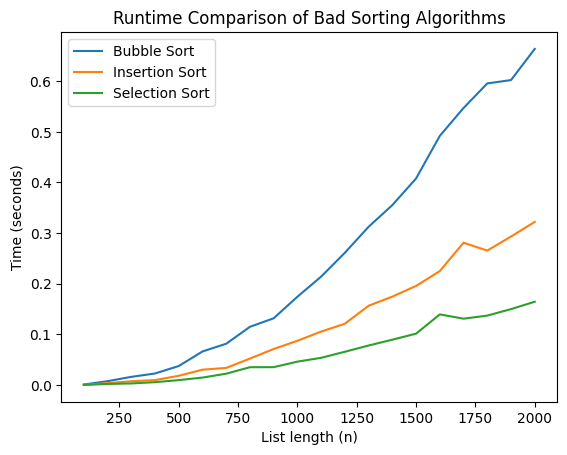

In [12]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, insertion_times, label="Insertion Sort")
plt.plot(lengths, selection_times, label="Selection Sort")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison of Bad Sorting Algorithms")
plt.legend()
plt.show()

Input sizes: 100, 200, 300, …, up to 2000 (increments of 100)

Number of runs per list size: 3 independent runs

Random lists: For each run, a new list of integers between 0 and 10,000 was generated using create_random_list

Algorithms tested: Bubble sort, insertion sort, and selection sort

Timing method: For each run, the time taken by each algorithm to sort the list was recorded using timeit.default_timer()

Data processing: For each list size, the minimum runtime across the 3 runs was used to actually plot the graphs

Plotting: These minimum runtimes were plotted against the corresponding list lengths 

In [13]:
lengths = list(range(10, 501, 10))
runs_per_length = 20
max_value = 10000

bubble_times = []
insertion_times = []
selection_times = []

for n in lengths:
    bubble_run_times = []
    insertion_run_times = []
    selection_run_times = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_run_times.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_run_times.append(timeit.default_timer() - start)

        L3 = L.copy()
        start = timeit.default_timer()
        selection_sort(L3)
        selection_run_times.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_run_times))
    insertion_times.append(min(insertion_run_times))
    selection_times.append(min(selection_run_times))

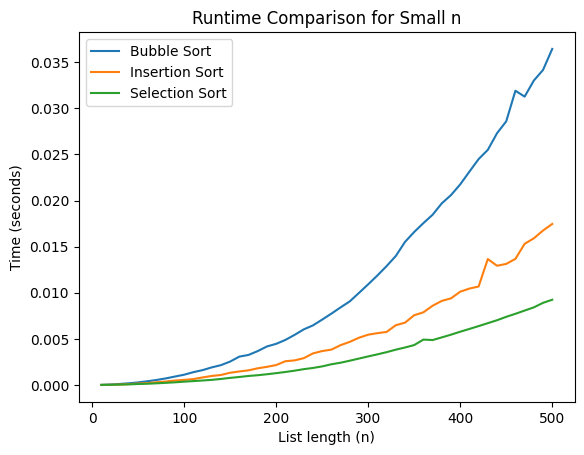

In [14]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, insertion_times, label="Insertion Sort")
plt.plot(lengths, selection_times, label="Selection Sort")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison for Small n")
plt.legend()
plt.show()

Input sizes (list lengths): 10, 20, 30, ... 500 (increments of 10)

Number of runs per list size: 20 independent runs 

Random lists: For each run, a new list of integers between 0 and 10,000 was generated using create_random_list

Algorithms tested: Bubble sort, insertion sort, and selection sort

Timing method: For each run, the time taken by each algorithm to sort the list was recorded using timeit.default_timer()

Data processing: For each list size, the minimum runtime across the 20 runs was used to actually plot the graphs

Plotting: These minimum runtimes were plotted against the corresponding list lengths 

Insertion sort consistently outperformed selection and bubble sort across small and large input sizes. All three algorithms displayed quadratic growth in runtime, as expected from their Θ(n²) time complexity. Bubble sort was the slowest due to unnecessary comparisons and swaps, while insertion sort terminates early which significantly speeds up the execution time.

**Experiment 2:**

In [15]:
def bubble_sort2(L):
    n = len(L)
    for i in range(n):
        j = 0
        while j < n - 1 - i:
            if L[j] > L[j + 1]:
                value = L[j]
                k = j + 1

                while k < n - i and L[k] < value:
                    L[k - 1] = L[k]
                    k += 1

                L[k - 1] = value
                j = k
            else:
                j += 1

In [16]:
def selection_sort2(L):
    left = 0
    right = len(L) - 1

    while left < right:
        min_index = left
        max_index = left

        for i in range(left, right + 1):
            if L[i] < L[min_index]:
                min_index = i
            if L[i] > L[max_index]:
                max_index = i

       
        swap(L, left, min_index)

        
        if max_index == left:
            max_index = min_index

       
        swap(L, right, max_index)

        left += 1
        right -= 1

In [17]:
bubble_times = []
bubble2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    b1_runs = []
    b2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()               
        bubble_sort(L1)
        b1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        bubble_sort2(L2)
        b2_runs.append(timeit.default_timer() - start)

    bubble_times.append(min(b1_runs))
    bubble2_times.append(min(b2_runs))


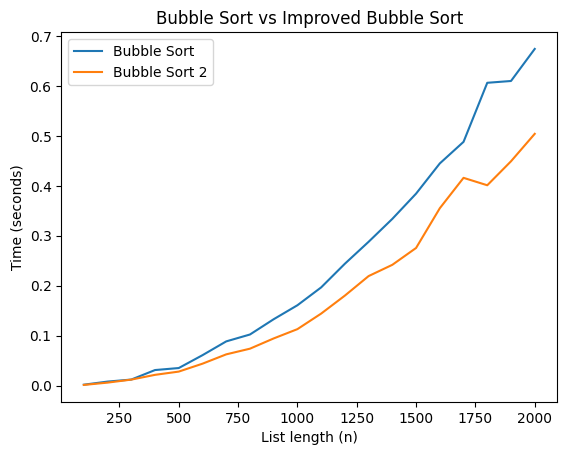

In [18]:
plt.plot(lengths, bubble_times, label="Bubble Sort")
plt.plot(lengths, bubble2_times, label="Bubble Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")
plt.title("Bubble Sort vs Improved Bubble Sort")
plt.legend()
plt.show()

In [21]:
selection_times = []
selection2_times = []

lengths = list(range(100, 2001, 100))
runs_per_length = 3
max_value = 10000

for n in lengths:
    s1_runs = []
    s2_runs = []

    for _ in range(runs_per_length):
        L = create_random_list(n, max_value)

        L1 = L.copy()
        start = timeit.default_timer()
        selection_sort(L1)
        s1_runs.append(timeit.default_timer() - start)

        L2 = L.copy()
        start = timeit.default_timer()
        selection_sort2(L2)
        s2_runs.append(timeit.default_timer() - start)

    selection_times.append(min(s1_runs))
    selection2_times.append(min(s2_runs))

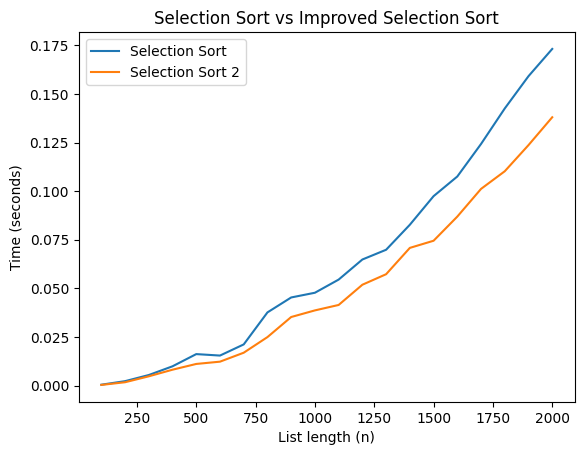

In [22]:
plt.plot(lengths, selection_times, label="Selection Sort")
plt.plot(lengths, selection2_times, label="Selection Sort 2")

plt.xlabel("List length (n)")
plt.ylabel("Time (seconds)")                                
plt.title("Selection Sort vs Improved Selection Sort")      
plt.legend()
plt.show()

Experiments were conducted on randomly generated lists of varying sizes. List lengths ranged from 100 to 2000 in increments of 100. Due to the quadratic time complexity for these "bad sorts", I believe an input size of 2000 is sufficient for both analytical purposes and keeping execution time reasonable. For each list length (100, 200, 300...), each algorithm was run 3 times on uniquely generated random lists containing integers between 0 and 10,000. The minimum runtime across the 3 runs was recorded for each algorithm and this data was used to plot the graph.

**Experiment 3**